<h1><b><u>Import Library</u></b><h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display

<h1><b><u>Memuat Dataset</u></b><h1>

In [2]:
df = pd.read_csv(
    "dataset/tourism_indonesia_2016-2026_clean.csv",
    parse_dates=["Tanggal"]
)

<h1><b><u>Ambil Data Detail</u></b><h1>

In [3]:
df_detail = df[
    df["Jenis Data"].isin([
        "Pintu Masuk",
        "Pintu Masuk Lainnya"
    ])
].copy()

<h1><b><u>Agregasi Bulanan</u></b><h1>

In [4]:
monthly = (
    df_detail
    .groupby("Tanggal")["Jumlah"]
    .sum(min_count=1)
    .sort_index()
)

<h1><b><u>Memisahkan Data</u></b><h1>
<p>Karena 2026 baru tersedia sampai Juli</p>

In [5]:
monthly_known = monthly.dropna()
print(monthly_known.head())
print(monthly_known.tail())

Tanggal
2016-01-01    814303.0
2016-02-01    887675.0
2016-03-01    914784.0
2016-04-01    901113.0
2016-05-01    914934.0
Name: Jumlah, dtype: float64
Tanggal
2026-03-01    1088166.0
2026-04-01    1248651.0
2026-05-01    1382087.0
2026-06-01    1386575.0
2026-07-01    1525037.0
Name: Jumlah, dtype: float64


<h1><b><u>Training dan Testing</u></b><h1>

In [6]:
monthly = (
    df_detail
    .groupby("Tanggal")["Jumlah"]
    .sum(min_count=1)
    .sort_index()
)

monthly = monthly.asfreq("MS")

print(monthly.head())
print(monthly.tail())

Tanggal
2016-01-01    814303.0
2016-02-01    887675.0
2016-03-01    914784.0
2016-04-01    901113.0
2016-05-01    914934.0
Freq: MS, Name: Jumlah, dtype: float64
Tanggal
2026-08-01   NaN
2026-09-01   NaN
2026-10-01   NaN
2026-11-01   NaN
2026-12-01   NaN
Freq: MS, Name: Jumlah, dtype: float64


In [7]:
monthly_known = monthly.dropna()

print("Jumlah data:", len(monthly_known))
print("Tanggal awal:", monthly_known.index.min())
print("Tanggal akhir:", monthly_known.index.max())

print("\n5 data terakhir:")
print(monthly_known.tail())

Jumlah data: 127
Tanggal awal: 2016-01-01 00:00:00
Tanggal akhir: 2026-07-01 00:00:00

5 data terakhir:
Tanggal
2026-03-01    1088166.0
2026-04-01    1248651.0
2026-05-01    1382087.0
2026-06-01    1386575.0
2026-07-01    1525037.0
Freq: MS, Name: Jumlah, dtype: float64


In [8]:
train = monthly_known[
    monthly_known.index < "2025-01-01"
]

test = monthly_known[
    (monthly_known.index >= "2025-01-01") &
    (monthly_known.index < "2026-01-01")
]

print("Jumlah data training :", len(train))
print("Jumlah data testing  :", len(test))

print("\nTraining:")
display(train.head())
display(train.tail())

print("\nTesting:")
display(test.head())
display(test.tail())

Jumlah data training : 108
Jumlah data testing  : 12

Training:


Tanggal
2016-01-01    814303.0
2016-02-01    887675.0
2016-03-01    914784.0
2016-04-01    901113.0
2016-05-01    914934.0
Freq: MS, Name: Jumlah, dtype: float64

Tanggal
2024-08-01    1339946.0
2024-09-01    1279258.0
2024-10-01    1193867.0
2024-11-01    1092067.0
2024-12-01    1228630.0
Freq: MS, Name: Jumlah, dtype: float64


Testing:


Tanggal
2025-01-01    1156012.0
2025-02-01    1022894.0
2025-03-01     984769.0
2025-04-01    1164539.0
2025-05-01    1306000.0
Freq: MS, Name: Jumlah, dtype: float64

Tanggal
2025-08-01    1505220.0
2025-09-01    1394910.0
2025-10-01    1348993.0
2025-11-01    1199007.0
2025-12-01    1405860.0
Freq: MS, Name: Jumlah, dtype: float64

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

<h1><b><u>Membuat Model SARIMA</u></b><h1>

In [9]:
model = SARIMAX(
    train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)

In [10]:
forecast = model_fit.forecast(
    steps=len(test)
)

<h1><b><u>Evaluasi Model</u></b><h1>

MAE


In [11]:
mae = mean_absolute_error(
    test,
    forecast
)

print("MAE:", mae)

MAE: 79871.19363496143


RMSE

In [12]:
rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("RMSE:", rmse)

RMSE: 88965.7334074642


MAPE

In [13]:
mape = (
    np.mean(
        np.abs(
            (test - forecast) / test
        )
    ) * 100
)

print("MAPE:", mape)

MAPE: 6.36466469020439


sMAPE

In [14]:
smape = (
    100
    * np.mean(
        2 * np.abs(test - forecast)
        / (np.abs(test) + np.abs(forecast))
    )
)


In [15]:
print(f"MAE   : {mae:,.2f}")
print(f"RMSE  : {rmse:,.2f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")

MAE   : 79,871.19
RMSE  : 88,965.73
MAPE  : 6.36%
sMAPE : 6.42%


<h1><b><u>Forecast Jumlah Wisatawan Agustus 2026 – Juli 2027</u></b><h1>

In [16]:
final_model = SARIMAX(
    monthly_known,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit(disp=False)

In [17]:
future_forecast = final_fit.forecast(
    steps=12
)

print(future_forecast)

2026-08-01    1.561461e+06
2026-09-01    1.485241e+06
2026-10-01    1.432476e+06
2026-11-01    1.326200e+06
2026-12-01    1.506809e+06
2027-01-01    1.343782e+06
2027-02-01    1.306394e+06
2027-03-01    1.267449e+06
2027-04-01    1.390154e+06
2027-05-01    1.509718e+06
2027-06-01    1.559543e+06
2027-07-01    1.667082e+06
Freq: MS, Name: predicted_mean, dtype: float64


<h1><b><u>Membuat Visualisasi Grafik SARIMA + Confidence Interval</u></b><h1>

In [18]:
final_fit = final_model.fit(disp=False)

In [19]:
final_model = SARIMAX(
    monthly_known,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit(disp=False)

forecast_result = final_fit.get_forecast(steps=12)

future_forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

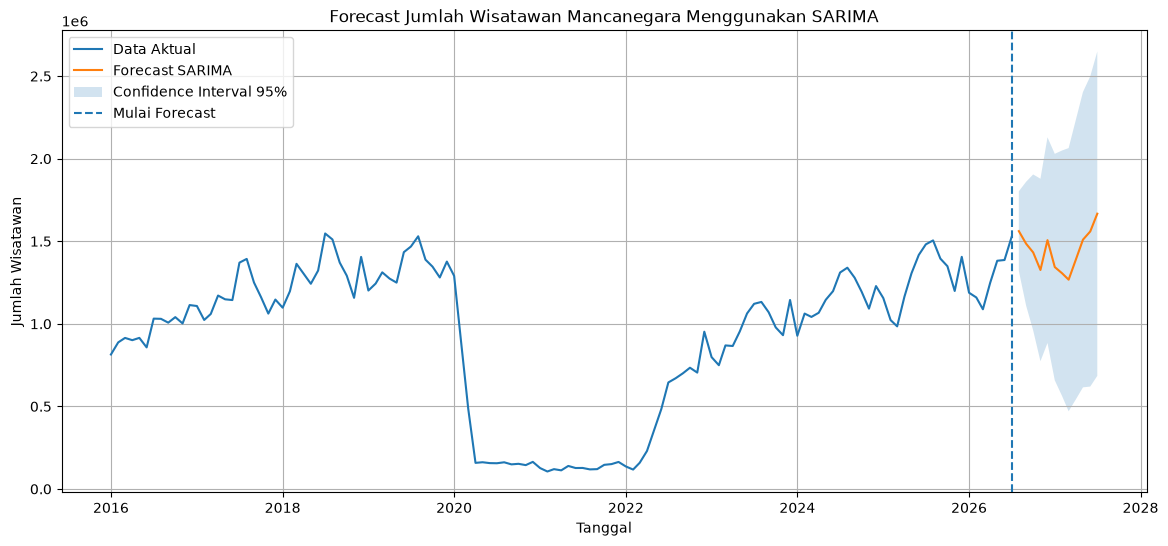

In [20]:
# Forecast 12 bulan ke depan beserta confidence interval
forecast_result = final_fit.get_forecast(steps=12)

future_forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Plot
plt.figure(figsize=(14, 6))

# Data aktual
plt.plot(
    monthly_known.index,
    monthly_known.values,
    label="Data Aktual"
)

# Forecast
plt.plot(
    future_forecast.index,
    future_forecast.values,
    label="Forecast SARIMA"
)

# Confidence interval 95%
plt.fill_between(
    future_forecast.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.2,
    label="Confidence Interval 95%"
)

# Batas data aktual dan forecast
plt.axvline(
    monthly_known.index[-1],
    linestyle="--",
    label="Mulai Forecast"
)

plt.title(
    "Forecast Jumlah Wisatawan Mancanegara Menggunakan SARIMA"
)

plt.xlabel("Tanggal")
plt.ylabel("Jumlah Wisatawan")

plt.legend()
plt.grid(True)

plt.show()

<h1><b><u>Membuat Tabel Hasil Forecast</u></b><h1>

In [21]:
future_forecast

2026-08-01    1.561461e+06
2026-09-01    1.485241e+06
2026-10-01    1.432476e+06
2026-11-01    1.326200e+06
2026-12-01    1.506809e+06
2027-01-01    1.343782e+06
2027-02-01    1.306394e+06
2027-03-01    1.267449e+06
2027-04-01    1.390154e+06
2027-05-01    1.509718e+06
2027-06-01    1.559543e+06
2027-07-01    1.667082e+06
Freq: MS, Name: predicted_mean, dtype: float64

In [22]:
from IPython.display import display

forecast_table = pd.DataFrame({
    "Tanggal": future_forecast.index,
    "Forecast": future_forecast.values,
    "Lower Bound": conf_int.iloc[:, 0].values,
    "Upper Bound": conf_int.iloc[:, 1].values
})

forecast_table["Tanggal"] = forecast_table["Tanggal"].dt.strftime("%B %Y")

forecast_table["Forecast"] = forecast_table["Forecast"].round(0).astype(int)
forecast_table["Lower Bound"] = forecast_table["Lower Bound"].round(0).astype(int)
forecast_table["Upper Bound"] = forecast_table["Upper Bound"].round(0).astype(int)

display(forecast_table)

,Tanggal,Forecast,Lower Bound,Upper Bound
0,August 2026,1561461,1320176,1802747
1,September 2026,1485241,1110234,1860248
2,October 2026,1432476,960204,1904749
3,November 2026,1326200,773522,1878878
4,December 2026,1506809,884022,2129596
5,January 2027,1343782,658016,2029548
6,February 2027,1306394,562965,2049823
7,March 2027,1267449,470519,2064380
8,April 2027,1390154,543095,2237213
9,May 2027,1509718,615335,2404101


----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

<h1><b><u>Perbandingan dengan Model Lain</u></b><h1>

In [23]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from prophet import Prophet

c:\Users\My MSI\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Membuat Fungsi Evaluasi

In [24]:
def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mape = (
        np.mean(
            np.abs((actual - predicted) / actual)
        ) * 100
    )

    smape = (
        100
        * np.mean(
            2 * np.abs(actual - predicted)
            / (np.abs(actual) + np.abs(predicted))
        )
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "sMAPE": smape
    }

In [25]:
results = []

<h1><b><u>MODEL 1 - Holt_Winters</u></b><h1>

In [26]:
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

hw_fit = hw_model.fit()

hw_forecast = hw_fit.forecast(
    steps=len(test)
)

In [27]:
hw_metrics = evaluate_model(
    test,
    hw_forecast
)

results.append({
    "Model": "Holt-Winters",
    **hw_metrics
})

print(hw_metrics)

{'MAE': 175262.03145164286, 'RMSE': np.float64(193497.40023109736), 'MAPE': np.float64(13.183496977573004), 'sMAPE': np.float64(14.18324384427109)}


<h1><b><u>MODEL 2 - SARIMA</u></b><h1>

In [28]:
sarima_model = SARIMAX(
    train,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.forecast(
    steps=len(test)
)

In [29]:
sarima_metrics = evaluate_model(
    test,
    sarima_forecast
)

results.append({
    "Model": "SARIMA",
    **sarima_metrics
})

print(sarima_metrics)

{'MAE': 79871.19363496143, 'RMSE': np.float64(88965.7334074642), 'MAPE': np.float64(6.36466469020439), 'sMAPE': np.float64(6.422679574351868)}


<h1><b><u>MODEL 3 - Prophet</u></b><h1>

In [30]:
prophet_train = train.reset_index()

prophet_train.columns = [
    "ds",
    "y"
]

prophet_train["ds"] = pd.to_datetime(
    prophet_train["ds"]
)

In [31]:
#Model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

07:48:59 - cmdstanpy - INFO - Chain [1] start processing
07:48:59 - cmdstanpy - INFO - Chain [1] done processing


In [32]:
#Forecast
future = pd.DataFrame({
    "ds": test.index
})

prophet_result = prophet_model.predict(future)

prophet_forecast = pd.Series(
    prophet_result["yhat"].values,
    index=test.index
)

print(prophet_forecast)

Tanggal
2025-01-01    620386.842880
2025-02-01    595689.194550
2025-03-01    603840.586817
2025-04-01    576042.645415
2025-05-01    601540.900324
2025-06-01    655470.076204
2025-07-01    767561.762164
2025-08-01    781267.662795
2025-09-01    720650.457654
2025-10-01    687351.811149
2025-11-01    628608.979624
2025-12-01    759260.420494
Freq: MS, dtype: float64


In [33]:
#Evaluasi
prophet_metrics = evaluate_model(
    test,
    prophet_forecast
)

results.append({
    "Model": "Prophet",
    **prophet_metrics
})

print("=== PROPHET ===")
print(f"MAE   : {prophet_metrics['MAE']:,.2f}")
print(f"RMSE  : {prophet_metrics['RMSE']:,.2f}")
print(f"MAPE  : {prophet_metrics['MAPE']:.2f}%")
print(f"sMAPE : {prophet_metrics['sMAPE']:.2f}%")

=== PROPHET ===
MAE   : 615,747.89
RMSE  : 626,272.32
MAPE  : 47.69%
sMAPE : 62.81%


<h1><b><u>MODEL 4 - Random Forest</u></b><h1>

In [34]:
def create_lag_features(series):
    data = pd.DataFrame(index=series.index)

    data["lag_1"] = series.shift(1)
    data["lag_2"] = series.shift(2)
    data["lag_3"] = series.shift(3)
    data["lag_6"] = series.shift(6)
    data["lag_12"] = series.shift(12)

    data["month"] = series.index.month

    return data

In [35]:
#Data Training
rf_train = create_lag_features(train)

rf_train["target"] = train

rf_train = rf_train.dropna()

X_rf = rf_train.drop(
    columns="target"
)

y_rf = rf_train["target"]

In [36]:
#Model
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    max_features="sqrt",
    min_samples_leaf=2
)

rf_model.fit(
    X_rf,
    y_rf
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decreas

In [37]:
#Recursive Forecast
#Jangan menggunakan nilai aktual 2025 sebagai lag ketika memprediksi bulan berikutnya karena itu akan menyebabkan data leakage.
history = train.copy()

rf_predictions = []

for date in test.index:

    features = pd.DataFrame({
        "lag_1": [history.iloc[-1]],
        "lag_2": [history.iloc[-2]],
        "lag_3": [history.iloc[-3]],
        "lag_6": [history.iloc[-6]],
        "lag_12": [history.iloc[-12]],
        "month": [date.month]
    })

    prediction = rf_model.predict(features)[0]

    rf_predictions.append(prediction)

    history.loc[date] = prediction

rf_forecast = pd.Series(
    rf_predictions,
    index=test.index
)

In [38]:
#Evaluasi
rf_metrics = evaluate_model(
    test,
    rf_forecast
)

results.append({
    "Model": "Random Forest",
    **rf_metrics
})

print(rf_metrics)

{'MAE': 106029.1519083997, 'RMSE': np.float64(125554.6199717998), 'MAPE': np.float64(8.70727485117994), 'sMAPE': np.float64(8.46997014213146)}


<h1><b><u>MODEL 5 - XGBoost</u></b><h1>

In [39]:
xgb_train = create_lag_features(train)

xgb_train["target"] = train

xgb_train = xgb_train.dropna()

X_xgb = xgb_train.drop(
    columns="target"
)

y_xgb = xgb_train["target"]

In [40]:
#Model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    X_xgb,
    y_xgb
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [41]:
#Recursive Forecast
history = train.copy()

xgb_predictions = []

for date in test.index:

    features = pd.DataFrame({
        "lag_1": [history.iloc[-1]],
        "lag_2": [history.iloc[-2]],
        "lag_3": [history.iloc[-3]],
        "lag_6": [history.iloc[-6]],
        "lag_12": [history.iloc[-12]],
        "month": [date.month]
    })

    prediction = xgb_model.predict(features)[0]

    xgb_predictions.append(prediction)

    history.loc[date] = prediction

xgb_forecast = pd.Series(
    xgb_predictions,
    index=test.index
)

In [42]:
#Evaluasi
xgb_metrics = evaluate_model(
    test,
    xgb_forecast
)

results.append({
    "Model": "XGBoost",
    **xgb_metrics
})

print(xgb_metrics)

{'MAE': 85525.97916666667, 'RMSE': np.float64(128949.50703859785), 'MAPE': np.float64(7.5788183620087075), 'sMAPE': np.float64(6.98268157567462)}


----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

<h1><b><u>Tabel Perbandingan</u></b><h1>

In [43]:
comparison = pd.DataFrame(results)

comparison = comparison.sort_values(
    by="MAPE"
).reset_index(drop=True)

comparison

,Model,MAE,RMSE,MAPE,sMAPE
0,SARIMA,79871.193635,88965.733407,6.364665,6.422680
1,XGBoost,85525.979167,128949.507039,7.578818,6.982682
2,Random Forest,106029.151908,125554.619972,8.707275,8.469970
3,Holt-Winters,175262.031452,193497.400231,13.183497,14.183244
4,Prophet,615747.888327,626272.316755,47.685959,62.808670


In [44]:
comparison.style.format({
    "MAE": "{:,.2f}",
    "RMSE": "{:,.2f}",
    "MAPE": "{:.2f}%",
    "sMAPE": "{:.2f}%"
})

,Model,MAE,RMSE,MAPE,sMAPE
0,SARIMA,"79,871.19","88,965.73",6.36%,6.42%
1,XGBoost,"85,525.98","128,949.51",7.58%,6.98%
2,Random Forest,"106,029.15","125,554.62",8.71%,8.47%
3,Holt-Winters,"175,262.03","193,497.40",13.18%,14.18%
4,Prophet,"615,747.89","626,272.32",47.69%,62.81%


<h1><b><u>Menentukan Model Terbaik</u></b><h1>

In [45]:
best_model = comparison.iloc[0]

print("=== MODEL TERBAIK ===")
print("Model :", best_model["Model"])
print(f"MAE   : {best_model['MAE']:,.2f}")
print(f"RMSE  : {best_model['RMSE']:,.2f}")
print(f"MAPE  : {best_model['MAPE']:.2f}%")
print(f"sMAPE : {best_model['sMAPE']:.2f}%")

=== MODEL TERBAIK ===
Model : SARIMA
MAE   : 79,871.19
RMSE  : 88,965.73
MAPE  : 6.36%
sMAPE : 6.42%


<h1><b><u>Visualisasi Perbandingan</u></b><h1>

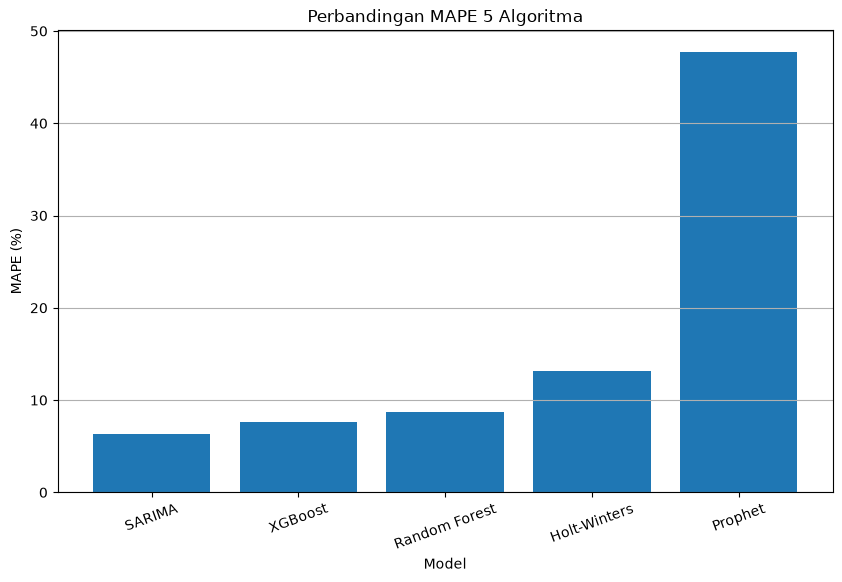

In [46]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Model"],
    comparison["MAPE"]
)

plt.title(
    "Perbandingan MAPE 5 Algoritma"
)

plt.xlabel("Model")
plt.ylabel("MAPE (%)")

plt.xticks(rotation=20)

plt.grid(axis="y")

plt.show()

In [47]:
import joblib
from pathlib import Path

# EXPORT MODEL SARIMA FINAL

# Pastikan final_fit sudah tersedia
if "final_fit" not in globals():
    raise NameError(
        "final_fit belum tersedia. "
        "Jalankan terlebih dahulu cell training model SARIMA final."
    )

# Pastikan monthly_known tersedia
if "monthly_known" not in globals():
    raise NameError(
        "monthly_known belum tersedia. "
        "Jalankan terlebih dahulu proses agregasi dan persiapan data."
    )

# FOLDER MODEL

model_dir = Path.cwd() / "model"
model_dir.mkdir(parents=True, exist_ok=True)

# Nama file
filename = "tourism_sarima_model.pkl"
file_path = model_dir / filename

# MODEL ARTIFACT

model_artifact = {
    "model": final_fit,
    "model_name": "SARIMA(0,1,1)(0,1,1,12)",
    "target": "Jumlah wisatawan mancanegara",
    "frequency": "MS",
    "seasonal_period": 12,
    "training_start": str(monthly_known.index.min()),
    "training_end": str(monthly_known.index.max()),
}

# SIMPAN MODEL

joblib.dump(
    model_artifact,
    file_path
)

print("Model berhasil disimpan.")
print(f"Lokasi : {file_path}")
print(f"Nama   : {filename}")

Model berhasil disimpan.
Lokasi : d:\POLMAN\Pr. Machine Learning\Code\Project\model\tourism_sarima_model.pkl
Nama   : tourism_sarima_model.pkl
